# Moaheed Ur Rehman
## 303-231051

# Amina
## 303-231054

# **TASK 1**

In [ ]:
# =============================================================================
# 1. IMPORTS
# =============================================================================
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve)

In [ ]:
import kagglehub
import os
import shutil

# The variable DATASET_DIR is expected to be defined in a previous cell,
# typically as DATASET_DIR = "/content/dataset".

print("Downloading dataset from Kaggle...")
# kagglehub.dataset_download returns the path to the extracted dataset files/folders.
# For "navoneel/brain-mri-images-for-brain-tumor-detection", this path usually contains
# a single subfolder named "brain_tumor_dataset" which holds the actual image categories.
download_root_path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")
print(f"Dataset downloaded to temporary location: {download_root_path}")

# Construct the path to the actual dataset content (containing 'tumor' and 'no_tumor' folders)
# based on the common structure of this Kaggle dataset.
source_content_path = os.path.join(download_root_path, "brain_tumor_dataset")

# Ensure the target DATASET_DIR exists and is empty before copying
if os.path.exists(DATASET_DIR):
    print(f"Clearing existing directory: {DATASET_DIR}")
    shutil.rmtree(DATASET_DIR)
os.makedirs(DATASET_DIR, exist_ok=True)

print(f"Copying dataset contents from {source_content_path} to {DATASET_DIR}...")

# Iterate through the items (subdirectories like 'tumor' and 'no_tumor') in the source directory
# and copy them into the DATASET_DIR. Use shutil.copytree for directories and shutil.copy2 for files.
for item in os.listdir(source_content_path):
    src_item_path = os.path.join(source_content_path, item)
    dst_item_path = os.path.join(DATASET_DIR, item)
    if os.path.isdir(src_item_path):
        # Use dirs_exist_ok=True if the destination directory for sub-items might already exist
        # However, since we rmtree DATASET_DIR above, this is generally not needed for initial copy
        shutil.copytree(src_item_path, dst_item_path)
    else:
        shutil.copy2(src_item_path, dst_item_path)

print(f"Dataset successfully prepared at {DATASET_DIR}.")
print(f"Contents of {DATASET_DIR}: {os.listdir(DATASET_DIR)}")

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Dataset downloaded to temporary location: /kaggle/input/brain-mri-images-for-brain-tumor-detection
Clearing existing directory: /content/dataset
Copying dataset contents from /kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset to /content/dataset...
Dataset successfully prepared at /content/dataset.
Contents of /content/dataset: ['no', 'yes']


# TASK 2

In [ ]:
# =============================================================================
# BRAIN TUMOR CLASSIFICATION (BraTS) — MobileNetV2 + Grad-CAM
# =============================================================================
# A lightweight, fast, binary (Tumor / No-Tumor) brain MRI classifier.
#
# Designed to run end-to-end in Google Colab on a T4 GPU in under 15 minutes.
#
# HOW TO USE IN COLAB:
#   1. Upload/mount your dataset so it looks like this:
#
#        /content/dataset/
#             train/
#                 tumor/       *.jpg|png
#                 no_tumor/    *.jpg|png
#             (optional) val/  and test/  with the same sub-folder structure
#
#      If you only have a single "train" folder, this script will
#      automatically split it into 70% train / 15% val / 15% test.
#
#   2. Set DATASET_DIR below to point at your data.
#   3. Run all cells (or run this script top to bottom).
#
# No placeholders — every section is fully implemented and runnable.
# =============================================================================




# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


# =============================================================================
# 2. DATASET LOADING
# =============================================================================
# EXPECTED FOLDER STRUCTURE (binary classification):
#
#   DATASET_DIR/
#       tumor/        -> MRI images WITH a tumor
#       no_tumor/      -> MRI images WITHOUT a tumor
#
# If your BraTS-derived data is already pre-split into train/val/test,
# set PRESPLIT = True and point TRAIN_DIR / VAL_DIR / TEST_DIR accordingly.

PRESPLIT = False                         # True if you already have train/val/test folders

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ["no", "yes"]      # index 0 = negative, index 1 = positive

SPLIT_DIR = "/content/brats_split"       # working directory for the 70/15/15 split


def build_split_from_flat_folders(source_dir, split_dir,
                                   train_ratio=0.70, val_ratio=0.15, test_ratio=0.15):
    """
    Takes a flat dataset (source_dir/class_name/*.jpg) and creates a
    70/15/15 train/val/test split by COPYING files (originals untouched)
    into split_dir/{train,val,test}/class_name/.
    """
    assert abs((train_ratio + val_ratio + test_ratio) - 1.0) < 1e-6, \
        "Split ratios must sum to 1.0"

    if os.path.exists(split_dir):
        shutil.rmtree(split_dir)

    classes = [d for d in os.listdir(source_dir)
               if os.path.isdir(os.path.join(source_dir, d))]
    print(f"Found classes: {classes}")

    for cls in classes:
        cls_path = os.path.join(source_dir, cls)
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)

        n = len(images)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        splits = {
            "train": images[:n_train],
            "val": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for split_name, file_list in splits.items():
            out_dir = os.path.join(split_dir, split_name, cls)
            os.makedirs(out_dir, exist_ok=True)
            for fname in file_list:
                shutil.copy(os.path.join(cls_path, fname),
                            os.path.join(out_dir, fname))

        print(f"  {cls}: {len(splits['train'])} train | "
              f"{len(splits['val'])} val | {len(splits['test'])} test")

    return (os.path.join(split_dir, "train"),
            os.path.join(split_dir, "val"),
            os.path.join(split_dir, "test"))


if PRESPLIT:
    # Point these at your already-split folders
    TRAIN_DIR = os.path.join(DATASET_DIR, "train")
    VAL_DIR = os.path.join(DATASET_DIR, "val")
    TEST_DIR = os.path.join(DATASET_DIR, "test")
else:
    TRAIN_DIR, VAL_DIR, TEST_DIR = build_split_from_flat_folders(
        DATASET_DIR, SPLIT_DIR, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15
    )


# =============================================================================
# 3. PREPROCESSING  &  4. DATA AUGMENTATION
# =============================================================================
# - Resize to 224x224 (handled by target_size in the generator)
# - Normalize pixel values using MobileNetV2's own preprocess_input
#   (scales pixels to [-1, 1], matching ImageNet pretraining)
# - Light augmentation ONLY on the training set: horizontal flip,
#   small rotation, small zoom. Validation/test use plain preprocessing.

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=10,      # small rotation
    zoom_range=0.10,        # small zoom
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=CLASS_NAMES,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Class indices:", train_generator.class_indices)


# =============================================================================
# 5. MODEL CREATION  —  MobileNetV2 (single pretrained CNN)
# =============================================================================
def build_model(input_shape=(224, 224, 3), fine_tune_last_n=20):
    """
    Builds a lightweight binary classifier on top of MobileNetV2.

    - Loads MobileNetV2 with ImageNet weights (no top).
    - Freezes all layers EXCEPT the last `fine_tune_last_n` layers,
      which are left trainable for light fine-tuning.
    - Adds GlobalAveragePooling2D -> Dropout -> Dense -> sigmoid head.
    """
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )

    # Freeze most of the backbone
    base_model.trainable = True
    for layer in base_model.layers[:-fine_tune_last_n]:
        layer.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="MobileNetV2_BrainTumorClassifier")
    return model, base_model


model, base_model = build_model(input_shape=(*IMG_SIZE, 3), fine_tune_last_n=20)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

model.summary()


# =============================================================================
# 6. TRAINING
# =============================================================================
EPOCHS = 20  # within the 10-15 range, keeps training fast

CHECKPOINT_PATH = "/content/best_brain_tumor_model.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)



TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found classes: ['no', 'yes']
  no: 68 train | 14 val | 16 test
  yes: 108 train | 23 val | 24 test
Found 176 images belonging to 2 classes.
Found 37 images belonging to 2 classes.
Found 40 images belonging to 2 classes.
Class indices: {'no': 0, 'yes': 1}


Model: "MobileNetV2_BrainTumorClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 1,288,129 (4.91 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6335 - auc: 0.5799 - loss: 0.7144
Epoch 1: val_loss improved from None to 0.57368, saving model to /content/best_brain_tumor_model.keras

Epoch 1: finished saving model to /content/best_brain_tumor_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.6648 - auc: 0.6560 - loss: 0.6571 - val_accuracy: 0.6486 - val_auc: 0.8121 - val_loss: 0.5737 - learning_rate: 1.0000e-04
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.8604 - auc: 0.8910 - loss: 0.4030
Epoch 2: val_loss did not improve from 0.57368
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 374ms/step - accuracy: 0.8636 - auc: 0.9141 - loss: 0.3713 - val_accuracy: 0.6216 - val_auc: 0.9208 - val_loss: 0.5821 - learning_rate: 1.0000e-04
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.8945 - auc: 0.9672 - loss: 0.2510
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 3: val_loss did not improve from 0.57368
6/6 ━━━━━━━━━━

# **TASK 3**

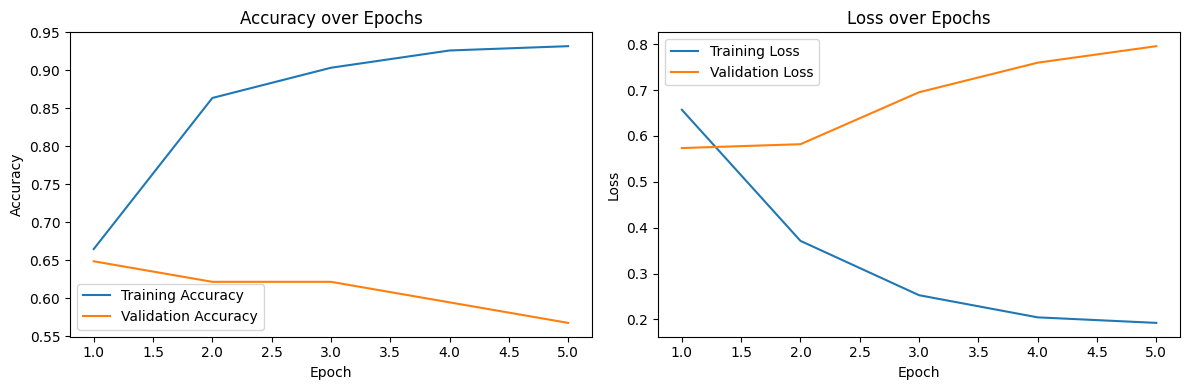

1/2 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step

TEST SET EVALUATION
Accuracy : 0.6750
Precision: 0.7200
Recall   : 0.7500
F1-score : 0.7347
ROC-AUC  : 0.7422

Confusion Matrix:
[[ 9  7]
 [ 6 18]]

Classification Report:
              precision    recall  f1-score   support

          no       0.60      0.56      0.58        16
         yes       0.72      0.75      0.73        24

    accuracy                           0.68        40
   macro avg       0.66      0.66      0.66        40
weighted avg       0.67      0.68      0.67        40



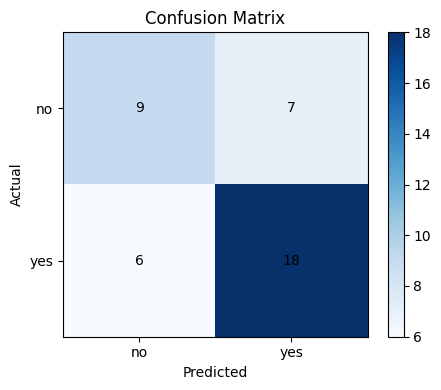

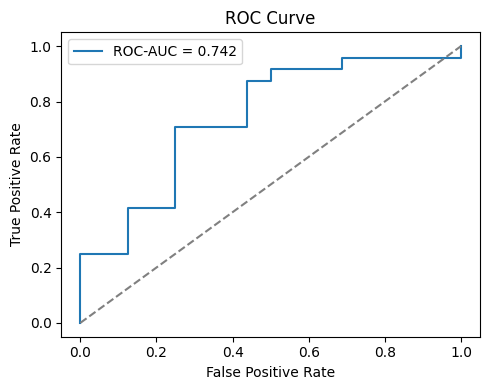

In [ ]:

# =============================================================================
# 7. EVALUATION
# =============================================================================
def evaluate_model(model, generator):
    """
    Runs full evaluation on a data generator and prints all standard
    classification metrics, the confusion matrix, and classification report.
    """
    generator.reset()
    y_true = generator.classes
    y_prob = model.predict(generator, verbose=1).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)

    print("\n" + "=" * 50)
    print("TEST SET EVALUATION")
    print("=" * 50)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticks([0, 1]); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title("Confusion Matrix")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
    fig.colorbar(im)
    plt.tight_layout()
    plt.show()

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1, "roc_auc": auc, "confusion_matrix": cm}


def plot_training_history(history):
    """Plots training/validation accuracy and loss curves."""
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_range, acc, label="Training Accuracy")
    axes[0].plot(epochs_range, val_acc, label="Validation Accuracy")
    axes[0].set_title("Accuracy over Epochs")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(epochs_range, loss, label="Training Loss")
    axes[1].plot(epochs_range, val_loss, label="Validation Loss")
    axes[1].set_title("Loss over Epochs")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_training_history(history)
metrics = evaluate_model(model, test_generator)

